# 09 — Model Evaluation & Threshold Analysis

**Tujuan notebook ini (Fase 8 roadmap):**
Bukan cuma bandingkan ROC-AUC. Pertanyaan utamanya:

> *"Jika tim marketing hanya bisa menghubungi 1.000 customer, apakah model membantu memilih 1.000 customer yang lebih baik daripada random?"*

Urutan analisis:
1. ROC Curve & PR Curve (3 model, validation set)
2. Precision@Top-K & Lift/Gain Analysis — **ini yang paling relevan secara bisnis**
3. Threshold Analysis
4. Pilih model terbaik (berdasarkan PR-AUC & lift, BUKAN ROC-AUC tertinggi)
5. Feature Importance
6. Probability Calibration Check (kondisional)
7. Evaluasi akhir di TEST SET (baru disentuh sekarang, sekali saja)

> ⚖️ Baseline (notebook 08) sudah dikunci dan di-commit. Notebook ini untuk MEMAHAMI hasil, bukan mengubah model dulu. Keputusan Feature Engineering V2 (kalau diperlukan) baru diambil SETELAH notebook ini selesai.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, brier_score_loss
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_DIR = Path("../data_processed")
MODELS_DIR = Path("../models")

with open(DATA_DIR / "train_val_test_split.pkl", "rb") as f:
    split_data = pickle.load(f)
X_train, y_train = split_data["X_train"], split_data["y_train"]
X_val, y_val = split_data["X_val"], split_data["y_val"]
X_test, y_test = split_data["X_test"], split_data["y_test"]

models = {}
for name, filename in [
    ("Logistic Regression", "logistic_regression.pkl"),
    ("Random Forest", "random_forest.pkl"),
    ("XGBoost", "xgboost.pkl"),
]:
    with open(MODELS_DIR / filename, "rb") as f:
        models[name] = pickle.load(f)

print("Model & data ter-load.")
print(f"Validation set: {len(X_val):,} ({y_val.mean()*100:.2f}% positive)")
print(f"Test set (belum disentuh)      : {len(X_test):,} ({y_test.mean()*100:.2f}% positive)")

baseline_rate = y_val.mean()
print(f"\nBaseline positive rate (kalau random pick): {baseline_rate*100:.2f}%")


Model & data ter-load.
Validation set: 8,758 (1.21% positive)
Test set (belum disentuh)      : 10,948 (1.21% positive)

Baseline positive rate (kalau random pick): 1.21%


---
## 1. ROC Curve & PR Curve (Validation Set, 3 Model)

PR-AUC adalah metrik utama (bukan pelengkap) karena imbalance 81:1.


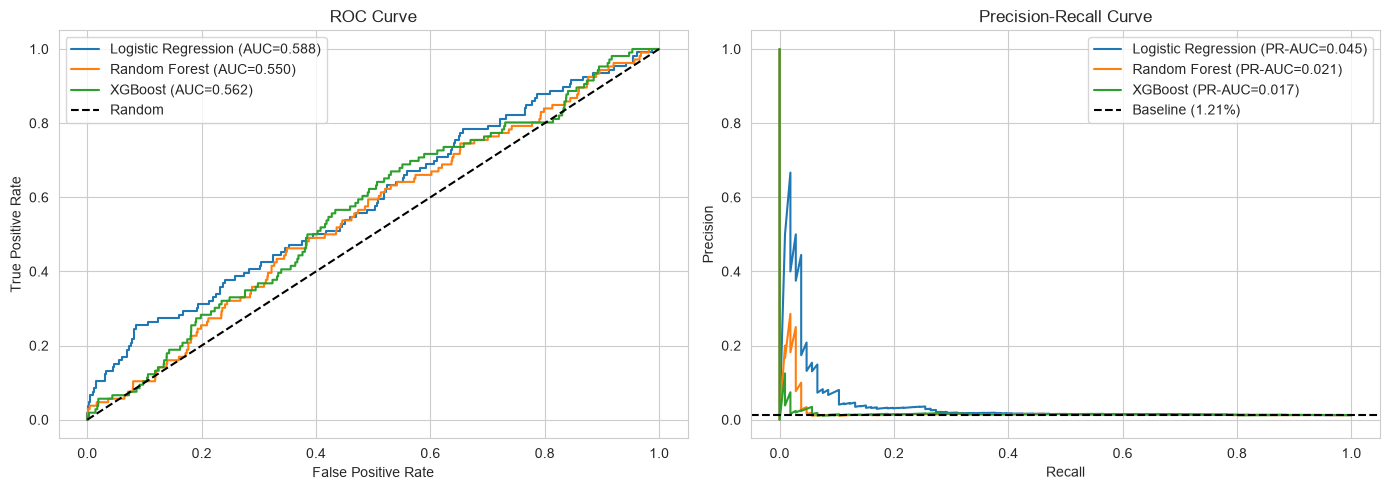

In [12]:
val_probas = {name: model.predict_proba(X_val)[:, 1] for name, model in models.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in val_probas.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for name, proba in val_probas.items():
    precision, recall, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")
axes[1].axhline(baseline_rate, color="k", linestyle="--", label=f"Baseline ({baseline_rate*100:.2f}%)")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 2. Precision@Top-K & Lift/Gain Analysis

**Pertanyaan bisnis utama**: kalau tim marketing cuma sanggup follow-up sejumlah customer tertentu (Top-K), seberapa jauh model ini lebih baik dari random pick?


In [13]:
def precision_at_k(y_true, y_proba, k_pct):
    n = len(y_true)
    k = int(n * k_pct / 100)
    top_k_idx = np.argsort(y_proba)[::-1][:k]
    return y_true.iloc[top_k_idx].mean() if hasattr(y_true, "iloc") else y_true[top_k_idx].mean()

k_percentages = [1, 5, 10, 20, 30]
lift_results = []

for name, proba in val_probas.items():
    for k_pct in k_percentages:
        precision_k = precision_at_k(y_val, proba, k_pct)
        lift = precision_k / baseline_rate if baseline_rate > 0 else np.nan
        lift_results.append({
            "model": name, "top_k_pct": k_pct,
            "precision_at_k": round(precision_k * 100, 2),
            "baseline_pct": round(baseline_rate * 100, 2),
            "lift": round(lift, 2),
        })

lift_df = pd.DataFrame(lift_results)
print("Precision@Top-K & Lift (Validation Set):")
print(lift_df.pivot(index="top_k_pct", columns="model", values="lift"))


Precision@Top-K & Lift (Validation Set):
model      Logistic Regression  Random Forest  XGBoost
top_k_pct                                             
1                         6.65           3.80     1.90
5                         3.03           1.13     1.32
10                        2.55           1.04     1.04
20                        1.56           1.27     1.42
30                        1.35           1.20     1.23


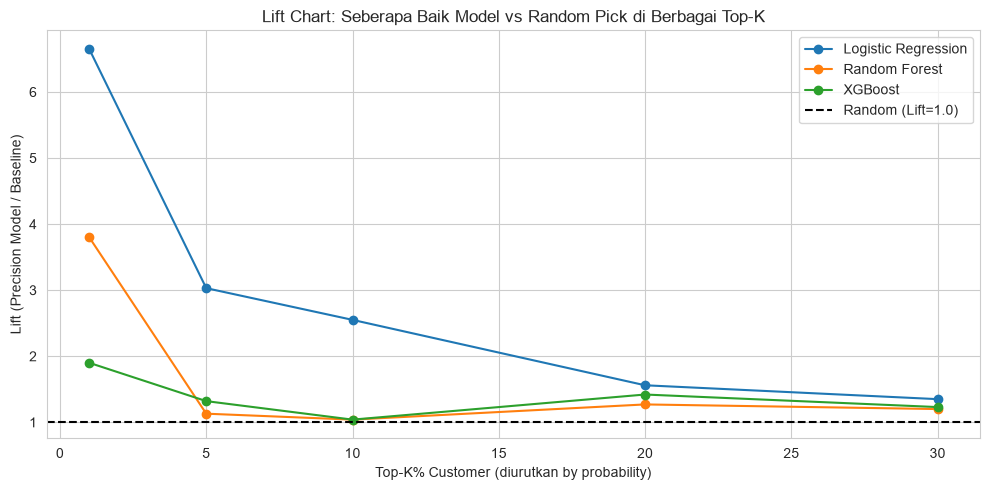


Interpretasi:
- Lift > 1 di Top-K kecil (1-5%) = model BERGUNA untuk prioritaskan campaign kecil/terfokus.
- Lift mendekati 1 di semua Top-K = model TIDAK lebih baik dari random pick.


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for name in models.keys():
    subset = lift_df[lift_df["model"] == name]
    ax.plot(subset["top_k_pct"], subset["lift"], marker="o", label=name)
ax.axhline(1.0, color="k", linestyle="--", label="Random (Lift=1.0)")
ax.set_title("Lift Chart: Seberapa Baik Model vs Random Pick di Berbagai Top-K")
ax.set_xlabel("Top-K% Customer (diurutkan by probability)")
ax.set_ylabel("Lift (Precision Model / Baseline)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretasi:")
print("- Lift > 1 di Top-K kecil (1-5%) = model BERGUNA untuk prioritaskan campaign kecil/terfokus.")
print("- Lift mendekati 1 di semua Top-K = model TIDAK lebih baik dari random pick.")


---
## 3. Threshold Analysis

Precision, Recall, F1 di berbagai threshold — untuk model dengan performa terbaik dari langkah 1-2.


In [15]:
# Pilih model terbaik berdasarkan PR-AUC (bukan ROC-AUC) untuk threshold analysis mendalam
pr_auc_scores = {name: average_precision_score(y_val, proba) for name, proba in val_probas.items()}
best_model_name = max(pr_auc_scores, key=pr_auc_scores.get)
print(f"Model dengan PR-AUC tertinggi (validation): {best_model_name} (PR-AUC={pr_auc_scores[best_model_name]:.4f})")

best_proba = val_probas[best_model_name]

thresholds = np.arange(0.1, 1.0, 0.05)
threshold_results = []
for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    if y_pred_t.sum() == 0:
        continue
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    threshold_results.append({
        "threshold": round(t, 2), "n_flagged": int(y_pred_t.sum()),
        "precision": round(precision, 3), "recall": round(recall, 3), "f1": round(f1, 3),
    })

threshold_df = pd.DataFrame(threshold_results)
print(f"\nThreshold analysis untuk {best_model_name}:")
print(threshold_df)


Model dengan PR-AUC tertinggi (validation): Logistic Regression (PR-AUC=0.0445)

Threshold analysis untuk Logistic Regression:
    threshold  n_flagged  precision  recall     f1
0        0.10       8750      0.012   1.000  0.024
1        0.15       8737      0.012   1.000  0.024
2        0.20       8716      0.012   1.000  0.024
3        0.25       8677      0.012   1.000  0.024
4        0.30       8578      0.012   0.991  0.024
5        0.35       8310      0.012   0.962  0.024
6        0.40       7384      0.013   0.896  0.025
7        0.45       5819      0.014   0.783  0.028
8        0.50       3792      0.014   0.509  0.028
9        0.55       1735      0.019   0.311  0.036
10       0.60        409      0.037   0.142  0.058
11       0.65        189      0.058   0.104  0.075
12       0.70        122      0.074   0.085  0.079
13       0.75         40      0.150   0.057  0.082
14       0.80         13      0.308   0.038  0.067
15       0.85          7      0.429   0.028  0.053
16    

---
## 4. Feature Importance


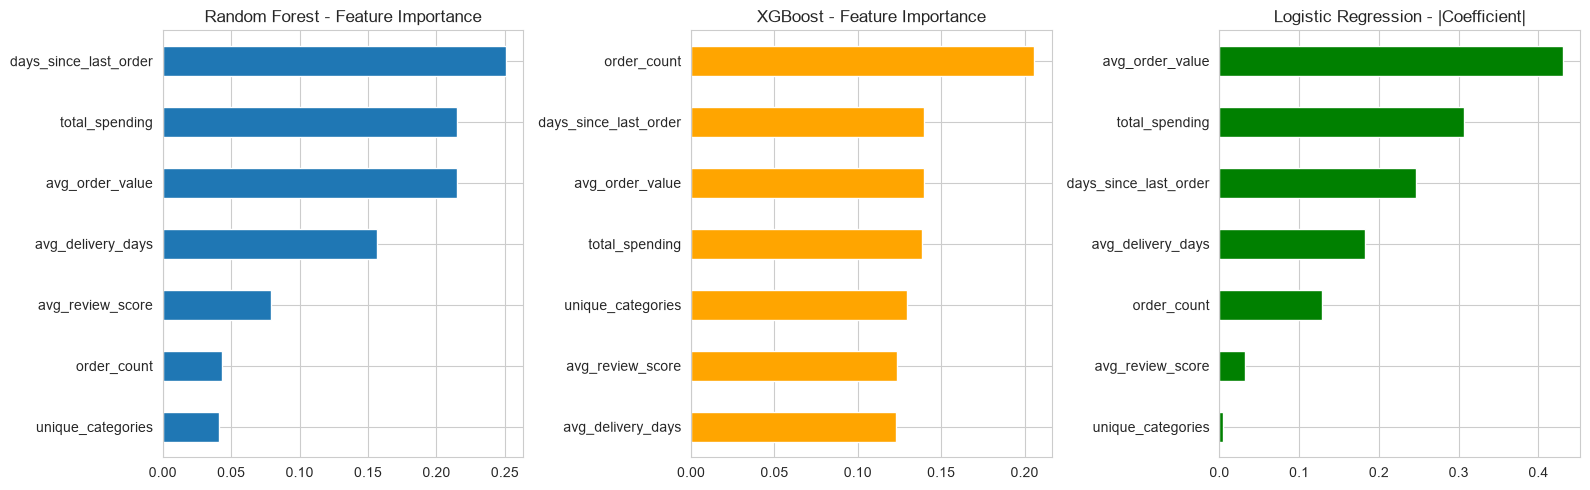

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

feature_names = X_train.columns.tolist()

# Random Forest
rf_importance = models["Random Forest"].named_steps["classifier"].feature_importances_
pd.Series(rf_importance, index=feature_names).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Random Forest - Feature Importance")

# XGBoost
xgb_importance = models["XGBoost"].named_steps["classifier"].feature_importances_
pd.Series(xgb_importance, index=feature_names).sort_values().plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("XGBoost - Feature Importance")

# Logistic Regression (coefficient, absolute value untuk urutan pentingnya)
logreg_coef = models["Logistic Regression"].named_steps["classifier"].coef_[0]
pd.Series(np.abs(logreg_coef), index=feature_names).sort_values().plot(kind="barh", ax=axes[2], color="green")
axes[2].set_title("Logistic Regression - |Coefficient|")

plt.tight_layout()
plt.show()


In [17]:
# Tabel koefisien Logistic Regression dengan arah (+/-) — bukan cuma magnitude
logreg_coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logreg_coef,
}).sort_values("coefficient", key=abs, ascending=False)

logreg_coef_table["direction"] = logreg_coef_table["coefficient"].apply(
    lambda x: "↑ Repeat likelihood" if x > 0 else "↓ Repeat likelihood"
)

print("Logistic Regression — Coefficient & Direction (setelah scaling, urut berdasarkan magnitude):")
print(logreg_coef_table.to_string(index=False))

print("\n⚠️ Catatan: ini predictive association/signal dari model, BUKAN causal driver.")
print("   Tidak bisa disimpulkan 'fitur X MENYEBABKAN customer repeat purchase' — hanya")
print("   'fitur X berasosiasi dengan probability repeat purchase yang lebih tinggi/rendah'.")

Logistic Regression — Coefficient & Direction (setelah scaling, urut berdasarkan magnitude):
              feature  coefficient           direction
      avg_order_value    -0.430598 ↓ Repeat likelihood
       total_spending     0.306501 ↑ Repeat likelihood
days_since_last_order    -0.246649 ↓ Repeat likelihood
    avg_delivery_days    -0.182193 ↓ Repeat likelihood
          order_count     0.128121 ↑ Repeat likelihood
     avg_review_score     0.032131 ↑ Repeat likelihood
    unique_categories    -0.004312 ↓ Repeat likelihood

⚠️ Catatan: ini predictive association/signal dari model, BUKAN causal driver.
   Tidak bisa disimpulkan 'fitur X MENYEBABKAN customer repeat purchase' — hanya
   'fitur X berasosiasi dengan probability repeat purchase yang lebih tinggi/rendah'.


In [18]:
# Tabel feature importance RF & XGBoost (tree-based, sudah unsigned secara alami)
importance_table = pd.DataFrame({
    "feature": feature_names,
    "rf_importance": rf_importance,
    "xgb_importance": xgb_importance,
}).sort_values("rf_importance", ascending=False)

print("Random Forest & XGBoost — Feature Importance:")
print(importance_table.to_string(index=False))

Random Forest & XGBoost — Feature Importance:
              feature  rf_importance  xgb_importance
days_since_last_order       0.250943        0.139985
       total_spending       0.214911        0.138448
      avg_order_value       0.214746        0.139462
    avg_delivery_days       0.156287        0.122801
     avg_review_score       0.078792        0.123597
          order_count       0.042957        0.205964
    unique_categories       0.041365        0.129742


---
## 5. Probability Calibration Check (Kondisional — Fase 8.2)

Cek dulu apakah calibration diperlukan, jangan otomatis calibrate.


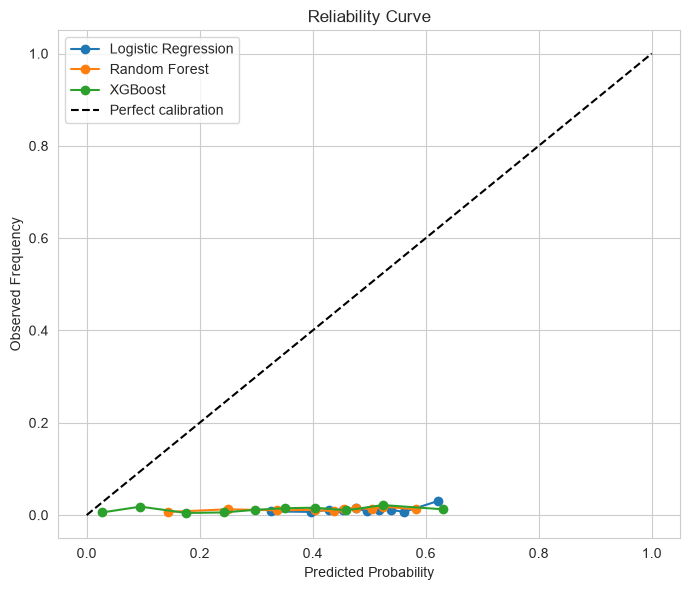

Brier Score (lebih rendah = lebih baik):
  Logistic Regression: 0.2389
  Random Forest: 0.1876
  XGBoost: 0.1399


In [19]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in val_probas.items():
    prob_true, prob_pred = calibration_curve(y_val, proba, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=name)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Observed Frequency")
ax.set_title("Reliability Curve")
ax.legend()
plt.tight_layout()
plt.show()

print("Brier Score (lebih rendah = lebih baik):")
for name, proba in val_probas.items():
    print(f"  {name}: {brier_score_loss(y_val, proba):.4f}")


**Keputusan calibration:** isi manual setelah lihat reliability curve di atas — kalau garis model terpilih jauh menyimpang dari diagonal, pertimbangkan `CalibratedClassifierCV`. Kalau relatif dekat diagonal, tidak perlu calibrate.


---
## 6. Evaluasi Akhir — TEST SET (disentuh sekali, di sini)

Ini titik pertama & terakhir test set dipakai. Hasilnya adalah estimasi paling jujur terhadap performa model di data yang benar-benar belum pernah dilihat.


In [20]:
final_model = models[best_model_name]
test_proba = final_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)

print(f"=== EVALUASI AKHIR: {best_model_name} di TEST SET ===")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}")
print(f"Baseline (positive rate test set): {y_test.mean()*100:.2f}%")

print(f"\nPrecision@Top-K di TEST SET:")
for k_pct in k_percentages:
    p_k = precision_at_k(y_test, test_proba, k_pct)
    lift = p_k / y_test.mean()
    print(f"  Top {k_pct}%: precision={p_k*100:.2f}%, lift={lift:.2f}x")


=== EVALUASI AKHIR: Logistic Regression di TEST SET ===
ROC-AUC : 0.5909
PR-AUC  : 0.0849
Baseline (positive rate test set): 1.21%

Precision@Top-K di TEST SET:
  Top 1%: precision=12.84%, lift=10.57x
  Top 5%: precision=4.39%, lift=3.61x
  Top 10%: precision=2.65%, lift=2.18x
  Top 20%: precision=2.01%, lift=1.65x
  Top 30%: precision=1.55%, lift=1.28x


---
## 7. Ringkasan Business Interpretation

**Isi manual setelah melihat semua hasil di atas.** Contoh kerangka jawaban:

> *"Model {best_model_name} mencapai ROC-AUC {test_roc_auc:.2f} dan PR-AUC {test_pr_auc:.3f} di test set. Meski ROC-AUC secara absolut tidak tinggi, analisis Precision@Top-K menunjukkan lift sebesar {lift}x di Top {k}% customer — artinya model {'CUKUP BERGUNA' if 'lift lebih dari 2x' else 'BELUM CUKUP BERGUNA'} untuk membantu tim marketing memprioritaskan campaign retensi dibanding random targeting. Keterbatasan utama: transaction-history-only features (frequency, monetary, recency dasar) punya predictive power terbatas untuk memprediksi repeat purchase 6 bulan ke depan pada dataset ini."*

**Keputusan Feature Engineering V2:** berdasarkan hasil lift di atas — kalau lift di Top 5-10% masih mendekati 1x (tidak jauh lebih baik dari random), itu jadi alasan kuat untuk kembali ke feature engineering dengan fitur temporal lebih kaya (`active_months`, `order_frequency_per_month`, `last_30d/60d/90d_orders`, `spending_trend`) sebagai eksperimen terpisah (V2), dibandingkan dengan V1 sebagai baseline.


---
## Definition of Done (Fase 8 — Model Evaluation)

- [ ] ROC Curve & PR Curve dibandingkan (3 model, validation set)
- [ ] Precision@Top-K & Lift dianalisis — pertanyaan bisnis utama terjawab
- [ ] Threshold analysis dilakukan untuk model terbaik
- [ ] Model terbaik dipilih berdasarkan PR-AUC & lift (BUKAN ROC-AUC tertinggi semata)
- [ ] Feature importance diperiksa (RF, XGBoost, Logistic)
- [ ] Probability calibration dicek (kondisional, keputusan calibrate/tidak didokumentasikan)
- [ ] Evaluasi akhir di TEST SET dilakukan SEKALI, hasilnya jujur dilaporkan
- [ ] Keputusan Feature Engineering V2 diambil berdasarkan bukti (lift), bukan asumsi

**Kalau lift menunjukkan model berguna:** lanjut ke `10_customer_scoring.ipynb`.
**Kalau lift lemah:** kembali ke feature engineering V2 sebagai eksperimen terpisah, re-run notebook 08 dengan fitur baru, bandingkan hasilnya dengan baseline V1 ini.
